# Predicting Sack Probability on NFL Pass Plays

**Goal:** estimate the probability that a dropback ends in a sack, using only information knowable *before the snap*.

**Data:** nflfastR play-by-play, 2021-2023, downloaded from the nflverse data releases. Modeling unit is `qb_dropback == 1`. League base sack rate is about 6.3%.

**Priority:** honest, leakage-free evaluation over a high score. Features are point-in-time, the split is by season, and the model is graded on calibration and log loss, not accuracy, which is meaningless at a 6% base rate.

##  1. Setup and data load

Load three seasons of play-by-play and filter to dropbacks, the only plays where a sack can occur. Confirms the modeling population and the base sack rate.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 60)
SEASONS = [2021, 2022, 2023]

EDA_COLS = [
    "season","week","game_id","play_id","posteam","defteam",
    "qb_dropback","qb_scramble","qb_kneel","qb_spike",
    "play_type","sack","pass_attempt",
    "down","ydstogo","yardline_100","goal_to_go",
    "shotgun","no_huddle","qtr","game_seconds_remaining",
    "score_differential","passer_player_name","passer_player_id","xpass",
]

In [2]:
import os
import urllib.request

# nflfastR play-by-play from the nflverse data releases, cached locally in data/
PBP_URL = "https://github.com/nflverse/nflverse-data/releases/download/pbp/play_by_play_{yr}.csv.gz"
os.makedirs("data", exist_ok=True)

frames = []
for yr in SEASONS:
    f = f"data/play_by_play_{yr}.csv.gz"
    if not os.path.exists(f):
        urllib.request.urlretrieve(PBP_URL.format(yr=yr), f)
    df = pd.read_csv(f, usecols=EDA_COLS, low_memory=False)
    frames.append(df)
    print(f"{yr}: {len(df):,} plays")

pbp = pd.concat(frames, ignore_index=True)
print(f"\nall seasons: {len(pbp):,} plays")

2021: 49,922 plays
2022: 49,434 plays
2023: 49,665 plays

all seasons: 149,021 plays


In [3]:
db = pbp[pbp["qb_dropback"] == 1].copy()

base_rate = db["sack"].mean()
print(f"dropbacks:        {len(db):,}")
print(f"sacks:            {int(db['sack'].sum()):,}")
print(f"base sack rate:   {base_rate:.3f}")

print("\nsack==1 by play_type:")
print(db.loc[db["sack"] == 1, "play_type"].value_counts(dropna=False))
print("\nkneels/spikes left in dropbacks (should be ~0):",
      int(db[["qb_kneel","qb_spike"]].sum().sum()))

dropbacks:        65,131
sacks:            4,130
base sack rate:   0.063

sack==1 by play_type:
play_type
pass    4130
Name: count, dtype: int64

kneels/spikes left in dropbacks (should be ~0): 0


## 2. Exploratory analysis: when do sacks happen?

Sack rate broken out by pre-snap situation. The point is to find which knowable-in-advance factors move the rate off its 6.3% baseline, and to motivate the features used later.

In [4]:
def rate_by(df, col, min_n=0):
    g = df.groupby(col, observed=True)["sack"].agg(n="size", sacks="sum")
    g["sack_rate"] = g["sacks"] / g["n"]
    return g[g["n"] >= min_n]

def plot_rate(g, title, xlabel):
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.bar(g.index.astype(str), g["sack_rate"], color="#3b6ea5")
    ax.axhline(base_rate, color="#a53b3b", ls="--", lw=1, label=f"overall {base_rate:.3f}")
    ax.set_ylabel("sack rate"); ax.set_xlabel(xlabel); ax.set_title(title)
    ax.legend()
    for i, v in enumerate(g["sack_rate"]):
        ax.text(i, v + 0.001, f"{v:.3f}", ha="center", fontsize=9)
    plt.tight_layout(); plt.show()

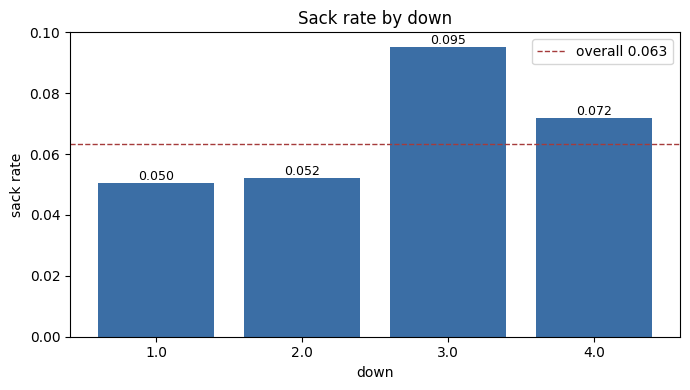

In [5]:
plot_rate(rate_by(db.dropna(subset=["down"]), "down"),
          "Sack rate by down", "down")

## Sack rate climbs with down, from about 5% on first down to 9.5% on third, because third down is when the defense knows a pass is likely and can pin its ears back.

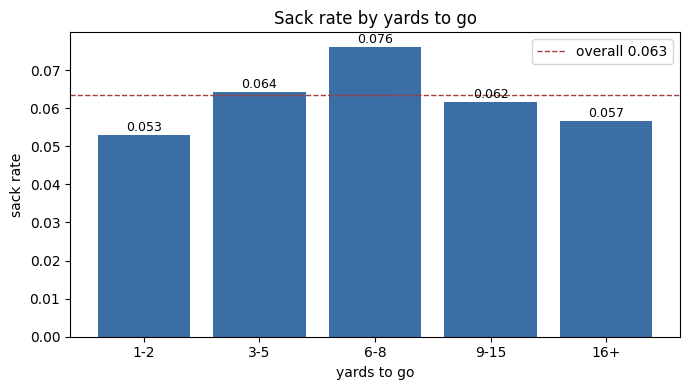

In [6]:
db["dist_bucket"] = pd.cut(db["ydstogo"], [0,2,5,8,15,100],
                           labels=["1-2","3-5","6-8","9-15","16+"])
plot_rate(rate_by(db.dropna(subset=["dist_bucket"]), "dist_bucket", min_n=50),
          "Sack rate by yards to go", "yards to go")

## Sack rate isn't linear in distance. It peaks in the medium 6-8 yard range and falls on long yardage. On obvious 3rd-and-long, the dropbacks that happen are mostly quick, short throws, the offense is often playing to set up a punt or put them in a manageable 4th down situation, so the ball comes out fast and the defense plays coverage over rush. The medium range is the real danger zone: the offense stays aggressive and the defense can pin its ears back.

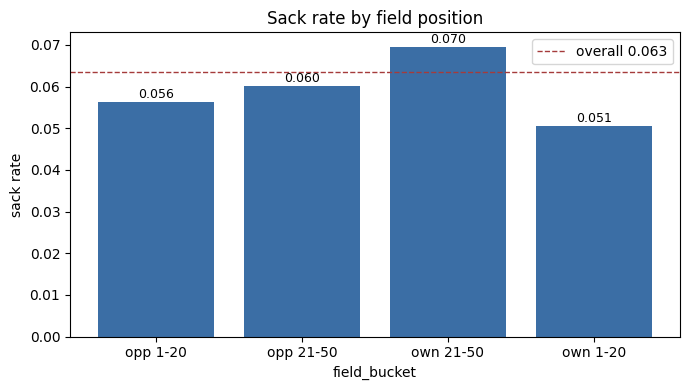

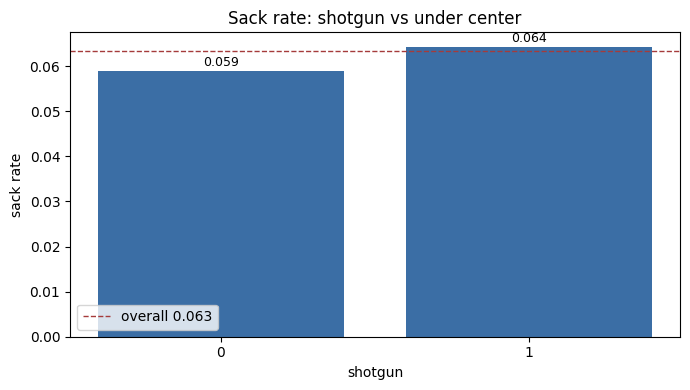

In [7]:
db["field_bucket"] = pd.cut(db["yardline_100"], [0,20,50,80,100],
                            labels=["opp 1-20","opp 21-50","own 21-50","own 1-20"])

for col, title in [("field_bucket","Sack rate by field position"),
                   ("shotgun","Sack rate: shotgun vs under center")]:
    plot_rate(rate_by(db.dropna(subset=[col]), col, min_n=50), title, col)

## Field position barely moves sack rate, the bars sit in a tight 5-7% band. The small wrinkle: rate is lowest deep in a team's own territory (own 1-20, 5.1%), where offenses tend to call quick, conservative plays. Shotgun shows a slightly higher rate (6.4% vs 5.9%), but that's selection, not cause, teams go shotgun on obvious passing downs, so shotgun snaps are concentrated in higher-risk situations to begin with.

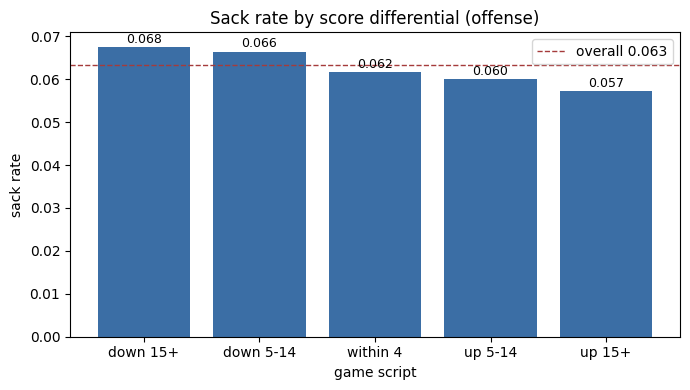

In [8]:
db["score_bucket"] = pd.cut(db["score_differential"], [-100,-14,-4,4,14,100],
    labels=["down 15+","down 5-14","within 4","up 5-14","up 15+"])
plot_rate(rate_by(db.dropna(subset=["score_bucket"]), "score_bucket"),
          "Sack rate by score differential (offense)", "game script")

## Sack rate falls steadily as the offense goes from trailing to leading. When the offense is down big, it spends more time in the pocket pushing for chunk plays downfield, and the defense, knowing the pass is coming, mixes in aggressive blitz and coverage looks to confuse the quarterback, so sacks climb. When the offense is up big, it throws short and conservative to manage the clock, and the ball comes out fast, so sacks drop.

## 3. Point-in-time features (the leakage rule)

The single rule that keeps this honest: a feature for a given game uses only games *before* it. Each prior is built with `cumsum().shift(1)` and shrunk toward the league rate for small samples. These QB, offense, and defense sack-rate priors are the model's main signal.

In [9]:
qb = (db.groupby("passer_player_name")["sack"]
        .agg(dropbacks="size", sacks="sum"))
qb["sack_rate"] = qb["sacks"] / qb["dropbacks"]
qb = qb[qb["dropbacks"] >= 300].sort_values("sack_rate", ascending=False)

print("Most sack-prone QBs (min 300 dropbacks):")
print(qb.head(10).round(3))
print("\nLeast sack-prone:")
print(qb.tail(10).round(3))

Most sack-prone QBs (min 300 dropbacks):
                    dropbacks  sacks  sack_rate
passer_player_name                             
J.Fields                 1097  135.0      0.123
B.Young                   589   62.0      0.105
Z.Wilson                 1107  113.0      0.102
T.Taylor                  321   32.0      0.100
D.Watson                  375   37.0      0.099
S.Howell                  701   68.0      0.097
B.Zappe                   334   31.0      0.093
R.Tannehill              1221  113.0      0.093
R.Wilson                 1464  133.0      0.091
D.Jones                  1158  104.0      0.090

Least sack-prone:
                    dropbacks  sacks  sack_rate
passer_player_name                             
T.Lawrence               1942   98.0      0.050
J.Goff                   1893   95.0      0.050
T.Tagovailoa             1460   72.0      0.049
T.Siemian                 390   19.0      0.049
J.Flacco                  508   24.0      0.047
J.Allen                  206

## Sack rate varies enormously by quarterback, from 12.3% (Fields) to 3.2% (Brady), nearly a 4x spread, far wider than any situational factor above. The split is intuitive: mobile QBs who hold the ball and extend plays take the most sacks, while quick-processing pocket passers take the fewest. This is the empirical case for the QB sack-rate prior built in the next section, and the reason it ends up the model's strongest single feature.

In [10]:
LEAGUE_RATE = db["sack"].mean()   # ~0.063, the shrink target
K = 100                            # pseudo-dropbacks of league prior (early-season shrink)

def prior_rate(game_tbl, key, num="sacks", den="dropbacks", league=LEAGUE_RATE, k=K):
    """Expanding prior rate within (key, season). cumsum THEN shift(1) so the
    current game is excluded and there's no NaN-propagation."""
    t = game_tbl.sort_values([key, "season", "week"]).copy()
    grp = t.groupby([key, "season"])
    prior_num = grp[num].transform(lambda s: s.cumsum().shift(1)).fillna(0)
    prior_den = grp[den].transform(lambda s: s.cumsum().shift(1)).fillna(0)
    t["prior_rate"] = (prior_num + k * league) / (prior_den + k)
    t["prior_den"]  = prior_den
    return t

qb_game = (db.dropna(subset=["passer_player_id"])
             .groupby(["season","week","game_id","passer_player_id"], as_index=False)
             .agg(dropbacks=("sack","size"), sacks=("sack","sum")))
qb_game = prior_rate(qb_game, "passer_player_id").rename(
    columns={"prior_rate":"qb_prior_sack_rate", "prior_den":"qb_prior_dropbacks"})

print(qb_game[["season","week","passer_player_id","dropbacks","sacks",
               "qb_prior_dropbacks","qb_prior_sack_rate"]].head(8).round(3))

     season  week passer_player_id  dropbacks  sacks  qb_prior_dropbacks  \
10     2021     1       00-0019596         50    0.0                 0.0   
39     2021     2       00-0019596         39    3.0                50.0   
106    2021     3       00-0019596         58    3.0                89.0   
142    2021     4       00-0019596         44    1.0               147.0   
167    2021     5       00-0019596         42    2.0               191.0   
219    2021     6       00-0019596         42    0.0               233.0   
227    2021     7       00-0019596         36    0.0               275.0   
294    2021     8       00-0019596         43    3.0               311.0   

     qb_prior_sack_rate  
10                0.063  
39                0.042  
106               0.049  
142               0.050  
167               0.046  
219               0.046  
227               0.041  
294               0.037  


In [11]:
off_game = (db.groupby(["season","week","game_id","posteam"], as_index=False)
              .agg(dropbacks=("sack","size"), sacks=("sack","sum")))
off_game = prior_rate(off_game, "posteam").rename(columns={"prior_rate":"off_prior_sack_rate"})

def_game = (db.groupby(["season","week","game_id","defteam"], as_index=False)
              .agg(dropbacks=("sack","size"), sacks=("sack","sum")))
def_game = prior_rate(def_game, "defteam").rename(columns={"prior_rate":"def_prior_sack_rate"})

print(off_game[["season","week","posteam","off_prior_sack_rate"]].head(4).round(3))
print(def_game[["season","week","defteam","def_prior_sack_rate"]].head(4).round(3))

    season  week posteam  off_prior_sack_rate
0     2021     1     ARI                0.063
52    2021     2     ARI                0.062
64    2021     3     ARI                0.064
96    2021     4     ARI                0.053
    season  week defteam  def_prior_sack_rate
0     2021     1     ARI                0.063
52    2021     2     ARI                0.086
64    2021     3     ARI                0.075
96    2021     4     ARI                0.075


In [12]:
model_df = (db
    .merge(qb_game[["game_id","passer_player_id","qb_prior_sack_rate","qb_prior_dropbacks"]],
           on=["game_id","passer_player_id"], how="left")
    .merge(off_game[["game_id","posteam","off_prior_sack_rate"]],
           on=["game_id","posteam"], how="left")
    .merge(def_game[["game_id","defteam","def_prior_sack_rate"]],
           on=["game_id","defteam"], how="left"))

model_df["qb_prior_sack_rate"] = model_df["qb_prior_sack_rate"].fillna(LEAGUE_RATE)

print(f"{len(model_df):,} dropback rows with priors attached\n")
print(model_df[["qb_prior_sack_rate","off_prior_sack_rate","def_prior_sack_rate"]].describe().round(3))

65,131 dropback rows with priors attached

       qb_prior_sack_rate  off_prior_sack_rate  def_prior_sack_rate
count           65131.000            65131.000            65131.000
mean                0.063                0.063                0.063
std                 0.015                0.015                0.012
min                 0.032                0.031                0.033
25%                 0.054                0.053                0.055
50%                 0.063                0.062                0.063
75%                 0.069                0.070                0.071
max                 0.147                0.132                0.104


## All three priors center on the league rate (~0.063), as expected. The QB prior has the widest spread (0.032 to 0.147), confirming that the quarterback carries more sack-rate signal than the offense or defense unit, consistent with the leaderboard above.

In [13]:
first = off_game.sort_values(["posteam","season","week"]).groupby(["posteam","season"]).head(1)
print("first-game offense priors all equal league shrink value:",
      np.allclose(first["off_prior_sack_rate"], LEAGUE_RATE))

sample_id = qb_game.sort_values("qb_prior_dropbacks", ascending=False)["passer_player_id"].iloc[0]
chk = qb_game[qb_game["passer_player_id"] == sample_id].sort_values(["season","week"])
print("\nspot-check QB (prior should always trail the cumulative sacks):")
print(chk[["season","week","dropbacks","sacks","qb_prior_dropbacks","qb_prior_sack_rate"]].head(6).round(3))

first-game offense priors all equal league shrink value: True

spot-check QB (prior should always trail the cumulative sacks):
     season  week  dropbacks  sacks  qb_prior_dropbacks  qb_prior_sack_rate
10     2021     1         50    0.0                 0.0               0.063
39     2021     2         39    3.0                50.0               0.042
106    2021     3         58    3.0                89.0               0.049
142    2021     4         44    1.0               147.0               0.050
167    2021     5         42    2.0               191.0               0.046
219    2021     6         42    0.0               233.0               0.046


## Leakage check. Every team's first game of a season sits exactly at the league shrink value, since there is no prior data to update from. The QB spot-check confirms each week's prior reflects only the weeks before it, never the current game. This is the core discipline of the project: no feature can see the play it is trying to predict.

## 4. Assemble the model table

One row per dropback: pre-snap game state, the point-in-time priors, and the target. Split by season (train 2021-22, test 2023), never random, so no future game informs the past.

In [14]:
# Every feature here is knowable PRE-SNAP. No play-outcome columns.
FEATURES = [
    "down","ydstogo","yardline_100",
    "shotgun","no_huddle","qtr","game_seconds_remaining",
    "score_differential","xpass",
    "qb_prior_sack_rate","off_prior_sack_rate","def_prior_sack_rate",
]

print("NaN counts per feature (only non-zero shown):")
print(model_df[FEATURES].isna().sum()[lambda s: s > 0])

mt = model_df.dropna(subset=FEATURES + ["sack"]).copy()
print(f"\nrows before: {len(model_df):,}   after dropna: {len(mt):,}   "
      f"dropped: {len(model_df) - len(mt):,}")

# Time-based split: train on past, test on the most recent season.
# Never a random split, since that would leak future games into training.
train = mt[mt["season"].isin([2021, 2022])]
test  = mt[mt["season"] == 2023]
X_train, y_train = train[FEATURES].astype("float64"), train["sack"]
X_test,  y_test  = test[FEATURES].astype("float64"),  test["sack"]
print(f"\ntrain: {len(train):,} rows (sack {y_train.mean():.3f})")
print(f"test:  {len(test):,} rows (sack {y_test.mean():.3f})")

NaN counts per feature (only non-zero shown):
down     285
xpass    285
dtype: int64

rows before: 65,131   after dropna: 64,846   dropped: 285

train: 43,106 rows (sack 0.062)
test:  21,740 rows (sack 0.067)


## 5. Calibrated logistic baseline

An interpretable starting model. Graded on log loss, Brier, and a calibration curve, since accuracy is useless at a 6% base rate. Compared against the dumbest honest baseline: always predict the league rate.

--- 2023 test metrics ---
                     model   base-rate
log loss            0.2421      0.2463
brier               0.0621      0.0626
roc auc             0.6030      0.5000
pr auc              0.0973      0.0671


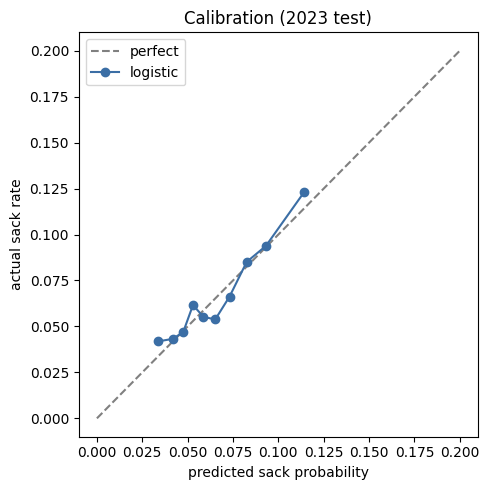


coefficients:
shotgun                  -0.269
no_huddle                -0.239
ydstogo                  -0.000
score_differential        0.023
off_prior_sack_rate       0.062
def_prior_sack_rate       0.063
yardline_100              0.089
qb_prior_sack_rate        0.116
game_seconds_remaining    0.156
qtr                       0.178
down                      0.370
xpass                     0.476
dtype: float64


In [15]:
# calibrated logistic baseline
import warnings
from sklearn.exceptions import DataConversionWarning
np.seterr(all="ignore")
warnings.filterwarnings("ignore")
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (log_loss, brier_score_loss,
                             roc_auc_score, average_precision_score)
from sklearn.calibration import calibration_curve

# RobustScaler uses the interquartile range, not the standard deviation,
# so low-variance binary columns (shotgun, no_huddle) don't cause a
# divide-by-zero in scaling.
logit = make_pipeline(RobustScaler(), LogisticRegression(max_iter=1000))
logit.fit(X_train, y_train)
p_test = logit.predict_proba(X_test)[:, 1]

# Compare against the dumbest honest baseline: always predict the train base rate.
p_base = np.full(len(y_test), y_train.mean())

print("--- 2023 test metrics ---")
print(f"{'':16}{'model':>10}{'base-rate':>12}")
print(f"{'log loss':16}{log_loss(y_test, p_test):>10.4f}{log_loss(y_test, p_base):>12.4f}")
print(f"{'brier':16}{brier_score_loss(y_test, p_test):>10.4f}{brier_score_loss(y_test, p_base):>12.4f}")
print(f"{'roc auc':16}{roc_auc_score(y_test, p_test):>10.4f}{0.5:>12.4f}")
print(f"{'pr auc':16}{average_precision_score(y_test, p_test):>10.4f}{y_test.mean():>12.4f}")

# Calibration curve: does a predicted 8% actually happen ~8% of the time?
frac_pos, mean_pred = calibration_curve(y_test, p_test, n_bins=10, strategy="quantile")
fig, ax = plt.subplots(figsize=(5, 5))
ax.plot([0, 0.2], [0, 0.2], "--", color="gray", label="perfect")
ax.plot(mean_pred, frac_pos, "o-", color="#3b6ea5", label="logistic")
ax.set_xlabel("predicted sack probability"); ax.set_ylabel("actual sack rate")
ax.set_title("Calibration (2023 test)"); ax.legend(); plt.tight_layout(); plt.show()

# Standardized coefficients: which pre-snap signals move the probability.
coefs = pd.Series(logit.named_steps["logisticregression"].coef_[0],
                  index=FEATURES).sort_values()
print("\ncoefficients:")
print(coefs.round(3))

## The logistic model beats the always-predict-base-rate baseline on every metric (log loss 0.2421 vs 0.2463, ROC-AUC 0.60 vs 0.50). More important than the small edge is calibration: the curve tracks the diagonal closely, so a predicted 8% sack probability really does occur about 8% of the time. That is the property a probability model is graded on, and accuracy would be meaningless here at a 6% base rate. The coefficients are intuitive: pass expectation (xpass), down, and the QB prior push sack probability up, while shotgun and no-huddle (faster throws) push it down.

## 6. Does model complexity help? (gradient boosting)

A calibrated gradient-boosted model on the identical features and split. If a nonlinear model with automatic interactions barely beats the linear baseline, the ceiling is set by missing pre-snap information, not model choice.

                 logloss    brier     roc       pr
base-rate         0.2463   0.0626  0.5000   0.0671
logistic          0.2421   0.0621  0.6030   0.0973
grad boost        0.2414   0.0619  0.6064   0.1034


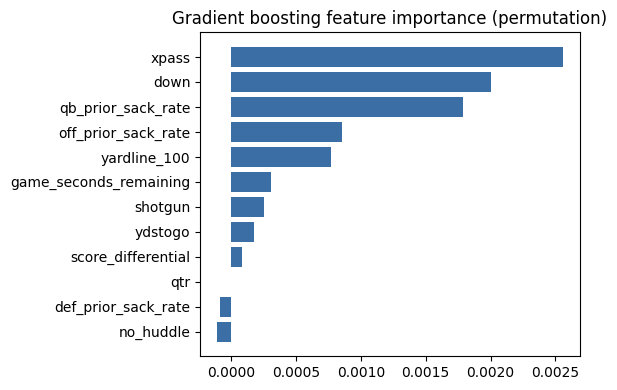

In [16]:
# ---- Gradient boosting: does model complexity help? ----
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.inspection import permutation_importance

# Boosted trees are miscalibrated out of the box, so wrap in isotonic
# calibration (cv=3 on the training data) since calibration is the priority here.
gb = HistGradientBoostingClassifier(max_depth=4, learning_rate=0.05,
                                    max_iter=300, l2_regularization=1.0)
gb_cal = CalibratedClassifierCV(gb, method="isotonic", cv=3).fit(X_train, y_train)
p_gb = gb_cal.predict_proba(X_test)[:, 1]

# Head-to-head on the same 2023 test set.
def metric_row(name, p):
    return (f"{name:14}{log_loss(y_test,p):>10.4f}{brier_score_loss(y_test,p):>9.4f}"
            f"{roc_auc_score(y_test,p):>8.4f}{average_precision_score(y_test,p):>9.4f}")

print(f"{'':14}{'logloss':>10}{'brier':>9}{'roc':>8}{'pr':>9}")
print(metric_row("base-rate", p_base))
print(metric_row("logistic",  p_test))
print(metric_row("grad boost", p_gb))

# Feature importance via permutation on the test set.
gb.fit(X_train, y_train)
perm = permutation_importance(gb, X_test, y_test, n_repeats=5,
                              scoring="neg_log_loss", random_state=0)
imp = pd.Series(perm.importances_mean, index=FEATURES).sort_values()
fig, ax = plt.subplots(figsize=(6, 4))
ax.barh(imp.index, imp.values, color="#3b6ea5")
ax.set_title("Gradient boosting feature importance (permutation)")
plt.tight_layout(); plt.show()

## A calibrated gradient-boosted model on the identical features and split beats the linear baseline only marginally (log loss 0.2414 vs 0.2421, ROC-AUC 0.606 vs 0.603). A flexible nonlinear model with automatic interactions finding almost no additional signal is itself the finding: the ceiling is set by missing pre-snap information, not model complexity. The two models also agree on the top features (xpass, down, the QB prior), a useful consistency check.

## 7. Situation predictor

Returns a sack probability for any pre-snap situation. The QB enters as a continuous prior rate, not a one-hot name, so the model generalizes to any quarterback, including ones not in the data.

In [17]:
# predict_sack: probability for any pre-snap situation
qb_career = db.groupby("passer_player_name")["sack"].mean()  # each QB's known rate

def predict_sack(qb="T.Brady", down=3, ydstogo=4, yardline_100=50,
                 score_differential=11, qtr=4, game_seconds_remaining=420,
                 shotgun=1, no_huddle=0, xpass=0.7,
                 off_prior=LEAGUE_RATE, def_prior=LEAGUE_RATE):
    qb_prior = qb_career.get(qb, LEAGUE_RATE)   # league rate if QB unseen
    row = pd.DataFrame([{
        "down":down, "ydstogo":ydstogo, "yardline_100":yardline_100,
        "shotgun":shotgun, "no_huddle":no_huddle,
        "qtr":qtr, "game_seconds_remaining":game_seconds_remaining,
        "score_differential":score_differential, "xpass":xpass,
        "qb_prior_sack_rate":qb_prior, "off_prior_sack_rate":off_prior,
        "def_prior_sack_rate":def_prior,
    }])[FEATURES]
    return float(logit.predict_proba(row)[:, 1][0])

print(f"Brady, 4th Q, 3&4 at midfield, up 11:  {predict_sack():.1%}")
print(f"Fields, same exact spot:               {predict_sack(qb='J.Fields'):.1%}")
print(f"league base rate:                      {LEAGUE_RATE:.1%}")

Brady, 4th Q, 3&4 at midfield, up 11:  5.8%
Fields, same exact spot:               10.9%
league base rate:                      6.3%


In [20]:
# Example situations across the risk spectrum
scenarios = [
    ("Jackson, 4th Q, 3&4 midfield, up 11 (shotgun)",
     dict(qb="L.Jackson", down=3, ydstogo=4, yardline_100=50,
          score_differential=11, qtr=4, shotgun=1, xpass=0.7)),

    ("Mahomes, 1st&10 own 25, tie game, 2nd Q",
     dict(qb="P.Mahomes", down=1, ydstogo=10, yardline_100=75,
          score_differential=0, qtr=2, shotgun=1, xpass=0.45)),

    ("Lawrence, 3rd&12 own 20, down 7, late 4th (obvious pass)",
     dict(qb="T.Lawrence", down=3, ydstogo=12, yardline_100=80,
          score_differential=-7, qtr=4, game_seconds_remaining=180,
          shotgun=1, xpass=0.92)),

    ("Z.Wilson, 2nd&8 own 10, down 14, backed up",
     dict(qb="Z.Wilson", down=2, ydstogo=8, yardline_100=90,
          score_differential=-14, qtr=3, shotgun=0, xpass=0.6)),

    ("Allen, 1st&goal at the 5, tie game (red zone)",
     dict(qb="J.Allen", down=1, ydstogo=5, yardline_100=5,
          score_differential=0, qtr=2, shotgun=1, xpass=0.5)),

    ("Unknown rookie QB, 3rd&9 own 30, down 3, 4th Q",
     dict(qb="X.Unknown", down=3, ydstogo=9, yardline_100=70,
          score_differential=-3, qtr=4, shotgun=1, xpass=0.85)),
]

print(f"{'situation':<52}{'sack prob':>10}")
print("-" * 62)
for label, kw in scenarios:
    print(f"{label:<52}{predict_sack(**kw):>9.1%}")
print(f"\n{'league base rate':<52}{LEAGUE_RATE:>9.1%}")

situation                                            sack prob
--------------------------------------------------------------
Jackson, 4th Q, 3&4 midfield, up 11 (shotgun)            8.1%
Mahomes, 1st&10 own 25, tie game, 2nd Q                  2.9%
Lawrence, 3rd&12 own 20, down 7, late 4th (obvious pass)     8.3%
Z.Wilson, 2nd&8 own 10, down 14, backed up               8.8%
Allen, 1st&goal at the 5, tie game (red zone)            2.7%
Unknown rookie QB, 3rd&9 own 30, down 3, 4th Q           8.5%

league base rate                                         6.3%


In [19]:
# More example situations
scenarios_2 = [
    ("Brady, 2nd&3 opp 35, up 3, 3rd Q (manageable)",
     dict(qb="T.Brady", down=2, ydstogo=3, yardline_100=35,
          score_differential=3, qtr=3, shotgun=1, xpass=0.55)),

    ("Hurts, 3rd&7 own 40, tie game, 4th Q",
     dict(qb="J.Hurts", down=3, ydstogo=7, yardline_100=60,
          score_differential=0, qtr=4, shotgun=1, xpass=0.88)),

    ("Goff, 1st&10 opp 45, up 7, 2nd Q (play-action range)",
     dict(qb="J.Goff", down=1, ydstogo=10, yardline_100=45,
          score_differential=7, qtr=2, shotgun=0, xpass=0.4)),

    ("Stroud, 3rd&15 own 15, down 10, late 4th (max obvious pass)",
     dict(qb="C.Stroud", down=3, ydstogo=15, yardline_100=85,
          score_differential=-10, qtr=4, game_seconds_remaining=120,
          shotgun=1, xpass=0.95)),

    ("Cousins, 2nd&6 midfield, down 4, 4th Q, hurry-up",
     dict(qb="K.Cousins", down=2, ydstogo=6, yardline_100=50,
          score_differential=-4, qtr=4, game_seconds_remaining=90,
          shotgun=1, no_huddle=1, xpass=0.8)),
]

print(f"{'situation':<56}{'sack prob':>10}")
print("-" * 66)
for label, kw in scenarios_2:
    print(f"{label:<56}{predict_sack(**kw):>9.1%}")
print(f"\n{'league base rate':<56}{LEAGUE_RATE:>9.1%}")

situation                                                sack prob
------------------------------------------------------------------
Brady, 2nd&3 opp 35, up 3, 3rd Q (manageable)                3.6%
Hurts, 3rd&7 own 40, tie game, 4th Q                         8.7%
Goff, 1st&10 opp 45, up 7, 2nd Q (play-action range)         3.6%
Stroud, 3rd&15 own 15, down 10, late 4th (max obvious pass)     9.5%
Cousins, 2nd&6 midfield, down 4, 4th Q, hurry-up             4.8%

league base rate                                             6.3%


## The predictor returns a calibrated probability for any pre-snap situation, spanning a sack-resistant QB in a safe spot (under 3%) to a sack-prone QB or an obvious passing down (about 9 to 10%). The "unknown rookie" case shows the league-rate fallback: a quarterback the model never saw still gets a sensible estimate rather than an error. Note this is conditional on a dropback occurring, it answers "if this is a pass, how likely is a sack," not whether the next play will be a pass.

## 8. Findings and honest limitations

The model beats the always-predict-base-rate baseline on every metric, though the edge is modest (log loss 0.242 vs 0.246, ROC-AUC 0.60), which is the expected result for a pre-snap problem. The more important property is calibration: predicted probabilities track observed sack rates closely across the full range, so a forecast of 8% really does mean about 8%. The strongest pre-snap signals are pass expectation (xpass), down, and the QB's prior sack rate.

The ceiling is low by nature. What most determines a sack -- protection breakdown, coverage, and the QB's choice to hold the ball -- is not observable before the snap. A pre-snap model can set an honest baseline probability but cannot sharply separate sacks from non-sacks. That is the expected result, not a flaw.

Next steps: add the PFR pressure and blitz-rate features through the roster ID bridge, build a separate pass/run model so situations where a pass is unlikely are handled upstream, and test the probabilities against historical betting markets.

A gradient-boosted model on the same features barely improved on the linear baseline, which confirms the ceiling is set by missing pre-snap information rather than model complexity.